In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df_company = pd.read_csv("../data/raw/ai_company_adoption.csv")
df_industry = pd.read_csv("../data/raw/ai_industry_summary.csv")
df_country = pd.read_csv("../data/raw/country_ai_index.csv")

#### Check the Three Columns

In [14]:
df_company.columns

Index(['response_id', 'company_id', 'survey_year', 'quarter', 'country',
       'region', 'industry', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction',
       'survey_source', 'data_collection_meth

In [15]:
df_industry.columns

Index(['industry', 'avg_ai_adoption_rate', 'avg_productivity_change_percent',
       'avg_ai_maturity_score', 'avg_ai_failure_rate', 'avg_jobs_displaced',
       'avg_jobs_created', 'avg_customer_satisfaction'],
      dtype='object')

In [17]:
df_country.columns

Index(['country', 'region', 'gdp_per_capita', 'internet_penetration',
       'digital_maturity_index', 'country_ai_policy', 'ai_patent_filings_2024',
       'ai_researchers_per_million'],
      dtype='object')

In [18]:
# Select the required columns
df_industry[
    [
        "avg_ai_adoption_rate",
        "avg_productivity_change_percent",
        "avg_ai_maturity_score"
    ]
]

,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score
0,35.25,8.80,0.33
1,34.52,8.65,0.33
2,35.23,8.79,0.33
3,38.35,9.50,0.35
4,34.57,8.60,0.33
5,35.26,9.13,0.33
6,34.73,9.05,0.33
7,34.70,8.99,0.33
8,42.47,11.17,0.41


In [27]:
df_company[
    [
        "ai_adoption_rate",
        "productivity_change_percent",
        "ai_maturity_score"
    ]
].describe()

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
count,150000.000000,150000.000000,150000.000000
mean,36.414726,9.266996,0.344675
std,14.544096,5.637067,0.133820
min,0.000000,0.000000,0.000000
25%,26.430000,5.070000,0.250000
50%,36.320000,9.060000,0.341000
75%,46.200000,13.120000,0.435000
max,100.000000,34.360000,0.904000


#### Distribution (Histogram)
#### AI Adoption Rate

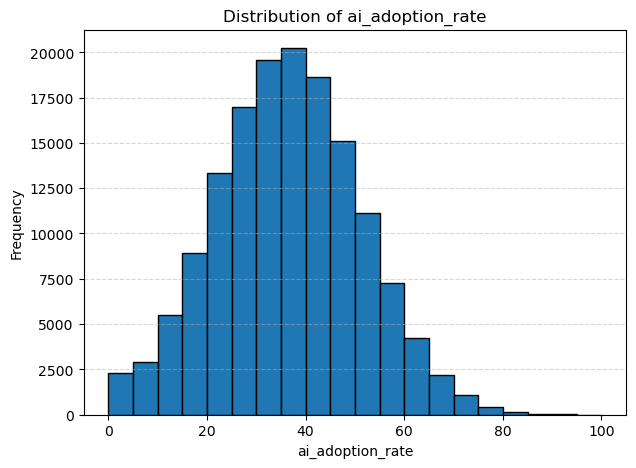

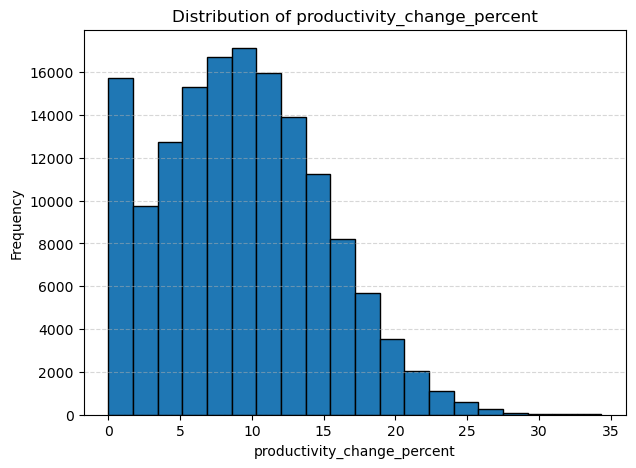

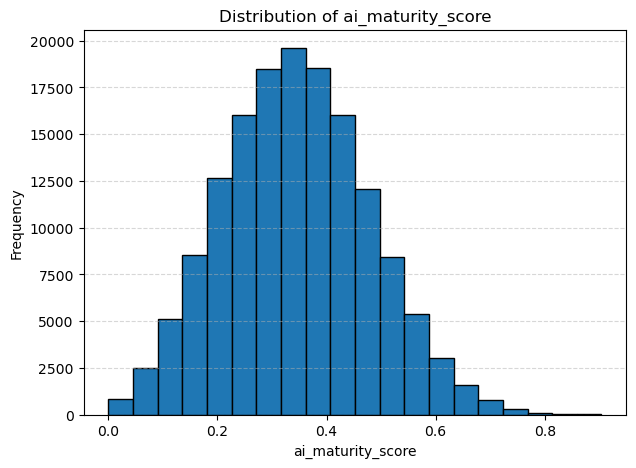

In [26]:
import matplotlib.pyplot as plt

columns = [
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]

for column in columns:
    plt.figure(figsize=(7,5))
    plt.hist(df_company[column], bins=20, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

In [28]:
### box plot

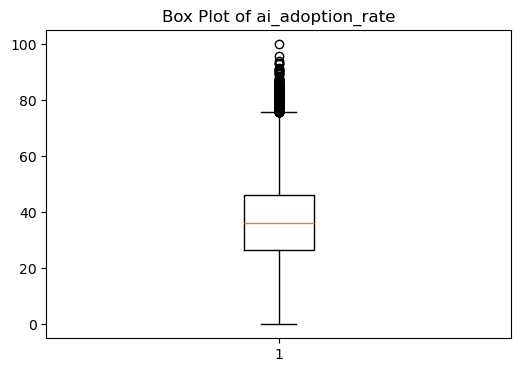

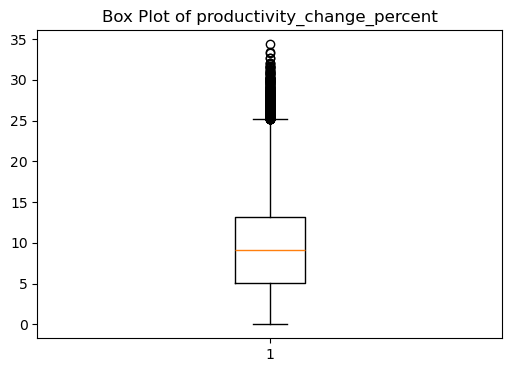

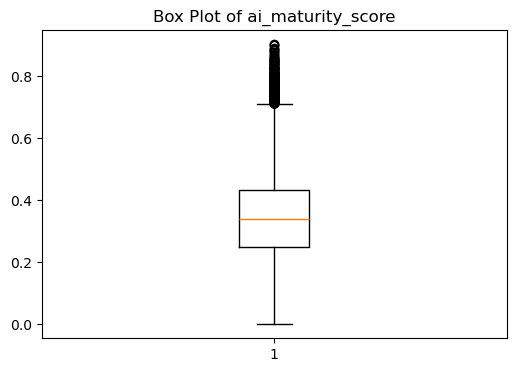

In [29]:
for column in columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_company[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

In [30]:
Q1 = df_company["ai_adoption_rate"].quantile(0.25)
Q3 = df_company["ai_adoption_rate"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-3.225000000000005
75.855


In [53]:
outliers = df_company[
    (df_company["ai_adoption_rate"] < lower) |
    (df_company["ai_adoption_rate"] > upper)
]

outliers.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method


In [32]:
print("Number of outliers:", len(outliers))

Number of outliers: 504


In [33]:
df_company = df_company[
    (df_company["ai_adoption_rate"] >= lower) &
    (df_company["ai_adoption_rate"] <= upper)
]

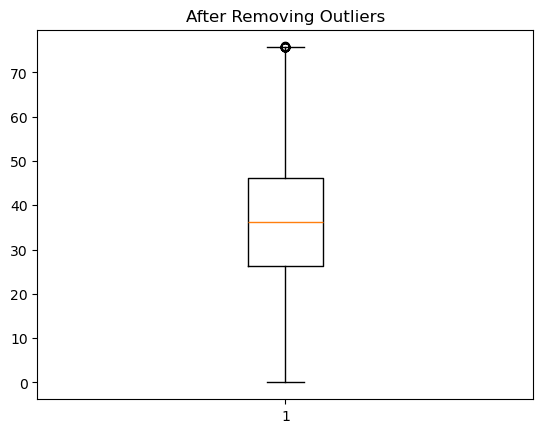

In [34]:
plt.boxplot(df_company["ai_adoption_rate"])
plt.title("After Removing Outliers")
plt.show()

#####  "The box plot indicates some high AI adoption values beyond the upper whisker. 
--- Since AI adoption rates between 0 and 100 are valid business observations, these values were retained for further analysis."

##### task 2  Segment analysis by region, survey_source

In [37]:
#### Segment Analysis by Region

In [38]:
region_analysis = df_company.groupby("region")[[
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]].mean()

region_analysis

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
region,,,
Africa,33.828609,8.622053,0.327099
Asia,35.935073,9.158791,0.340435
Europe,36.625755,9.325562,0.347406
North America,38.916599,9.891422,0.362698
Oceania,39.137179,9.947404,0.363687
South America,36.064060,9.115971,0.340079


In [40]:
### Visualize Region Analysis
### AI Adoption Rate

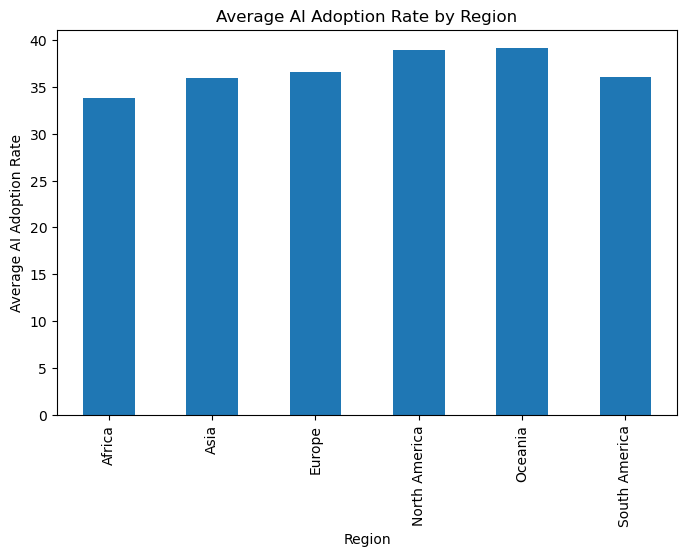

In [39]:
plt.figure(figsize=(8,5))

region_analysis["ai_adoption_rate"].plot(kind="bar")

plt.title("Average AI Adoption Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average AI Adoption Rate")

plt.show()

#### Productivity Change

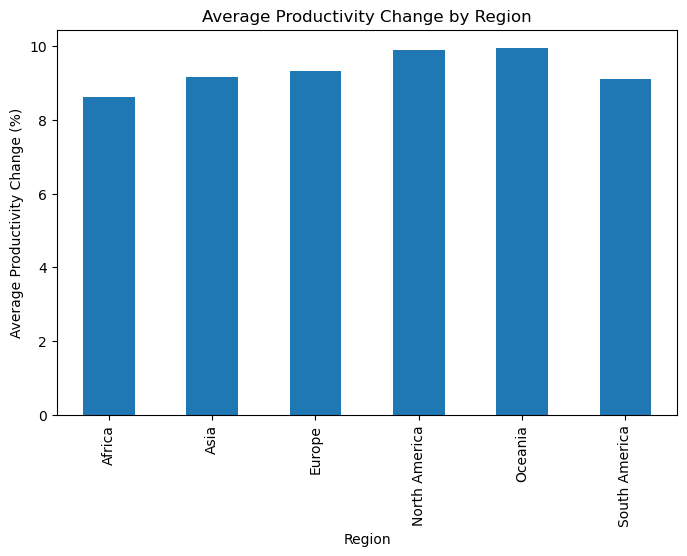

In [41]:
plt.figure(figsize=(8,5))

region_analysis["productivity_change_percent"].plot(kind="bar")

plt.title("Average Productivity Change by Region")
plt.xlabel("Region")
plt.ylabel("Average Productivity Change (%)")

plt.show()

In [42]:
### AI Maturity Score

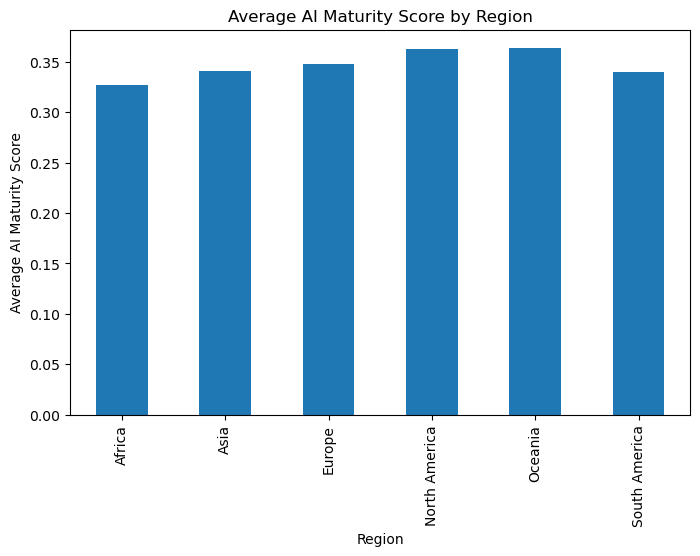

In [43]:
plt.figure(figsize=(8,5))

region_analysis["ai_maturity_score"].plot(kind="bar")

plt.title("Average AI Maturity Score by Region")
plt.xlabel("Region")
plt.ylabel("Average AI Maturity Score")

plt.show()

##### Segment Analysis by Survey Source

In [44]:
survey_analysis = df_company.groupby("survey_source")[[
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]].mean()

survey_analysis

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
survey_source,,,
Internal Corporate Survey,36.248730,9.239814,0.343798
LinkedIn Poll,36.259752,9.234955,0.343289
McKinsey Report,36.302615,9.256452,0.343600
WEF Survey,36.261826,9.178546,0.343367


In [45]:
#### Visualize Survey Source Analysis
#### AI Adoption Rate

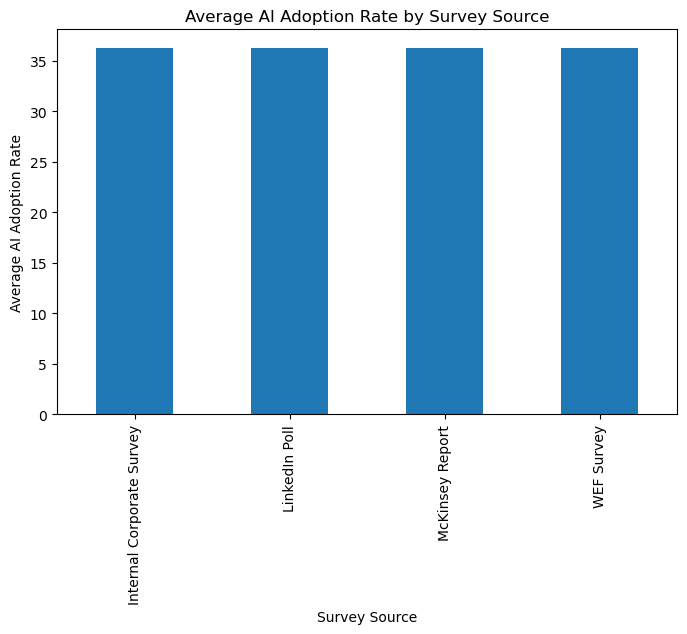

In [46]:
plt.figure(figsize=(8,5))

survey_analysis["ai_adoption_rate"].plot(kind="bar")

plt.title("Average AI Adoption Rate by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Average AI Adoption Rate")

plt.show()

In [47]:
### Productivity Change

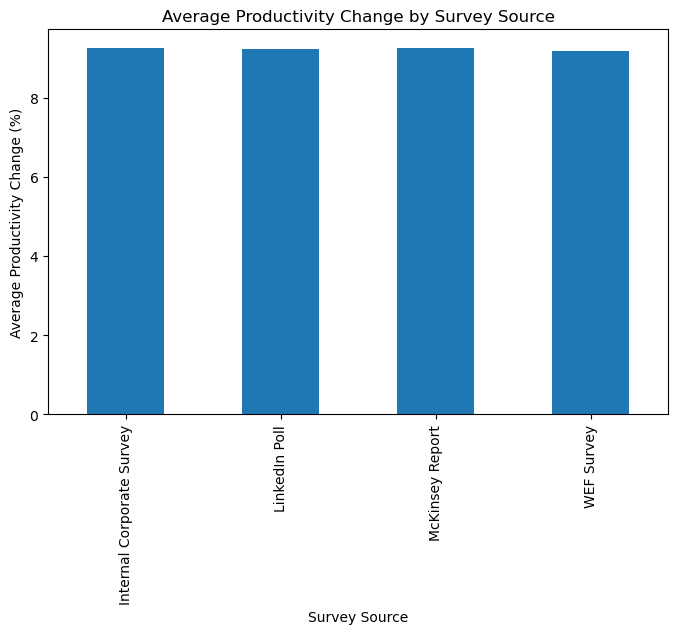

In [48]:
plt.figure(figsize=(8,5))

survey_analysis["productivity_change_percent"].plot(kind="bar")

plt.title("Average Productivity Change by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Average Productivity Change (%)")

plt.show()

In [49]:
#### AI Maturity Score

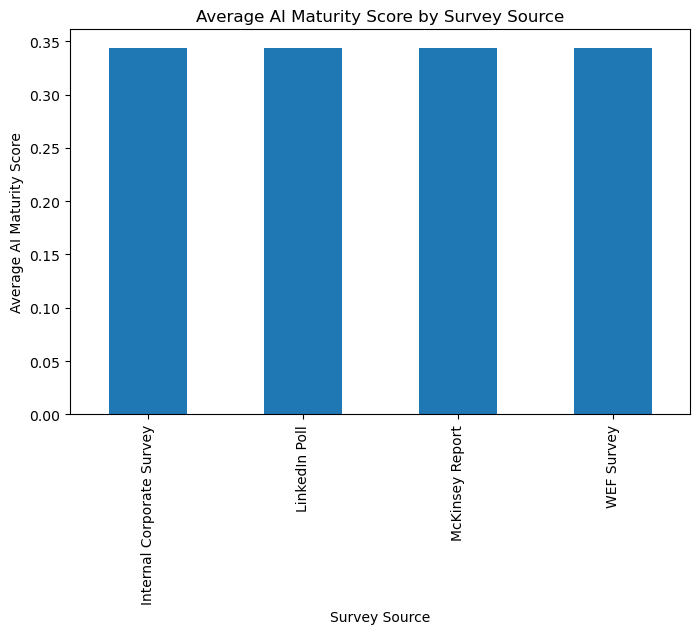

In [50]:
plt.figure(figsize=(8,5))

survey_analysis["ai_maturity_score"].plot(kind="bar")

plt.title("Average AI Maturity Score by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Average AI Maturity Score")

plt.show()

#### After creating the charts for Task 2 (Segment Analysis by Region and Survey Source), you should write a short summary based on what the charts show.

Here are professional summaries you can use and slightly modify based on your actual chart values.

### 1. Average AI Adoption Rate by Region
The bar chart compares the average AI adoption rate across different regions. It helps identify which regions have adopted AI more extensively. Regions with higher average adoption rates indicate greater AI implementation, while regions with lower values may have opportunities to improve AI adoption.

#### 2. Average Productivity Change by Region
This chart shows the average productivity improvement across regions after AI adoption. Some regions demonstrate higher productivity gains, suggesting that AI implementation has positively influenced operational efficiency. Regions with lower productivity improvements may require further optimization.

### 3. Average AI Maturity Score by Region
The AI maturity score varies across regions, indicating different levels of AI readiness and implementation maturity. Regions with higher scores are generally more advanced in integrating AI technologies into their business processes.

#### 4. Average AI Adoption Rate by Survey Source
The chart compares AI adoption rates reported by different survey sources. Although slight differences exist, the overall adoption rates are relatively consistent across sources, indicating reliable reporting of AI adoption trends.

#### 5. Average Productivity Change by Survey Source
Productivity improvements reported by different survey sources are broadly similar. Minor variations may reflect differences in sample populations or survey methodologies, but the overall trend suggests positive productivity gains from AI adoption.

#### 6. Average AI Maturity Score by Survey Source
AI maturity scores remain relatively consistent across survey sources. This indicates that organizations surveyed through different sources report comparable levels of AI maturity and readiness.

##### task 3 Derive date parts from survey_year, company_founding_year

In [56]:
### Check the Columns
df_company[["survey_year", "company_founding_year"]].head()

,survey_year,company_founding_year
0,2023,1994
1,2023,1994
2,2023,1994
3,2023,1994
4,2024,1994


In [57]:
df_company["survey_year"].value_counts().sort_index()

survey_year
2023    37395
2024    37380
2025    37371
2026    37350
Name: count, dtype: int64

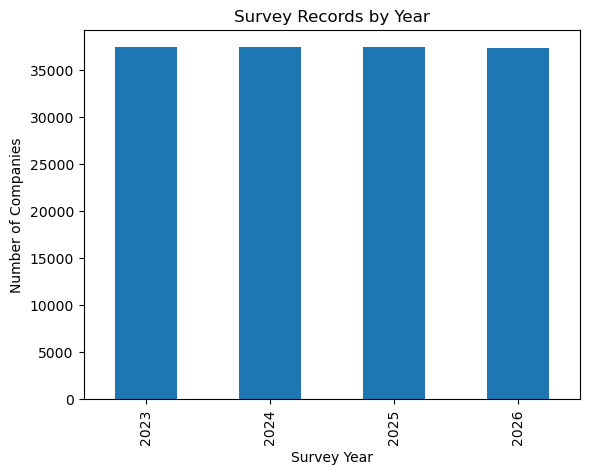

In [58]:
df_company["survey_year"].value_counts().sort_index().plot(kind="bar")

plt.title("Survey Records by Year")
plt.xlabel("Survey Year")
plt.ylabel("Number of Companies")

plt.show()